In [24]:
!pip install pennylane tqdm

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import matplotlib.pyplot as plt
import time

from tqdm import tqdm
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report

import pennylane as qml

In [26]:
ROOT_DIR = '/kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset'
TRAIN_DIR = ROOT_DIR + '/train'
TEST_DIR = ROOT_DIR + '/test'

IMG_SIZE = 224
BATCH_SIZE = 6
EPOCHS = 10
LR = 0.0001

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

Using Device: cuda


In [27]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

In [28]:
full_train_dataset = ImageFolder(TRAIN_DIR, transform=train_transform)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])
val_dataset.dataset.transform = val_test_transform

test_dataset = ImageFolder(TEST_DIR, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

class_names = full_train_dataset.classes
print("Classes:", class_names)

Classes: ['benign', 'malignant']


In [29]:
class QuantumLayer(nn.Module):
    def __init__(self, n_qubits=4, n_layers=2):
        super().__init__()

        self.n_qubits = n_qubits
        self.n_layers = n_layers

        self.dev = qml.device("default.qubit", wires=n_qubits)

        @qml.qnode(self.dev, interface="torch")
        def circuit(inputs, weights):
            for i in range(n_qubits):
                qml.RY(inputs[i], wires=i)

            for l in range(n_layers):
                for i in range(n_qubits):
                    qml.RZ(weights[l][i], wires=i)

                for i in range(n_qubits - 1):
                    qml.CNOT(wires=[i, i+1])

            return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

        weight_shapes = {"weights": (n_layers, n_qubits)}
        self.q_layer = qml.qnn.TorchLayer(circuit, weight_shapes)

    def forward(self, x):
        outputs = []
        for i in range(x.shape[0]):  # batch-safe
            outputs.append(self.q_layer(x[i]))
        return torch.stack(outputs)

In [30]:
class MobileNetV2_Quantum(nn.Module):
    def __init__(self):
        super().__init__()

        self.base = models.mobilenet_v2(weights="IMAGENET1K_V1")
        self.base.classifier = nn.Identity()

        # 🔥 Freeze 50%
        total_layers = len(self.base.features)
        freeze_layers = total_layers // 2

        for i, layer in enumerate(self.base.features):
            if i < freeze_layers:
                for param in layer.parameters():
                    param.requires_grad = False

        self.reducer = nn.Linear(1280, 4)
        self.quantum = QuantumLayer(4)
        self.fc = nn.Linear(4, 2)

    def forward(self, x):
        x = self.base(x)
        x = torch.tanh(self.reducer(x))  # stability
        x = self.quantum(x)
        x = self.fc(x)
        return x

model = MobileNetV2_Quantum().to(device)

In [31]:
for i, layer in enumerate(model.base.features):
    grad = any(p.requires_grad for p in layer.parameters())
    print(f"Layer {i}: {'Trainable' if grad else 'Frozen'}")

Layer 0: Frozen
Layer 1: Frozen
Layer 2: Frozen
Layer 3: Frozen
Layer 4: Frozen
Layer 5: Frozen
Layer 6: Frozen
Layer 7: Frozen
Layer 8: Frozen
Layer 9: Trainable
Layer 10: Trainable
Layer 11: Trainable
Layer 12: Trainable
Layer 13: Trainable
Layer 14: Trainable
Layer 15: Trainable
Layer 16: Trainable
Layer 17: Trainable
Layer 18: Trainable


In [32]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

In [33]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(EPOCHS):
    start_time = time.time()

    model.train()
    running_loss, correct, total = 0, 0, 0

    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{EPOCHS}]")

    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        loop.set_postfix(loss=loss.item())

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    # Validation
    model.eval()
    val_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    epoch_time = time.time() - start_time

    print(f"\nEpoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {train_loss:.3f}, Train Acc: {train_acc:.3f}, "
          f"Val Loss: {val_loss:.3f}, Val Acc: {val_acc:.3f}, "
          f"Time: {epoch_time:.2f}s\n")

Epoch [1/10]: 100%|██████████| 1281/1281 [03:09<00:00,  6.75it/s, loss=0.557]



Epoch [1/10] Train Loss: 0.625, Train Acc: 0.486, Val Loss: 0.605, Val Acc: 0.454, Time: 219.34s



Epoch [2/10]: 100%|██████████| 1281/1281 [03:16<00:00,  6.52it/s, loss=0.63] 



Epoch [2/10] Train Loss: 0.581, Train Acc: 0.486, Val Loss: 0.576, Val Acc: 0.454, Time: 224.38s



Epoch [3/10]: 100%|██████████| 1281/1281 [03:16<00:00,  6.51it/s, loss=0.509]


...


Epoch [8/10] Train Loss: 0.434, Train Acc: 0.938, Val Loss: 0.443, Val Acc: 0.926, Time: 222.86s



Epoch [9/10]: 100%|██████████| 1281/1281 [03:18<00:00,  6.45it/s, loss=0.354]



Epoch [9/10] Train Loss: 0.416, Train Acc: 0.938, Val Loss: 0.427, Val Acc: 0.926, Time: 227.48s



Epoch [10/10]: 100%|██████████| 1281/1281 [03:17<00:00,  6.47it/s, loss=0.393]



Epoch [10/10] Train Loss: 0.398, Train Acc: 0.938, Val Loss: 0.403, Val Acc: 0.935, Time: 225.43s



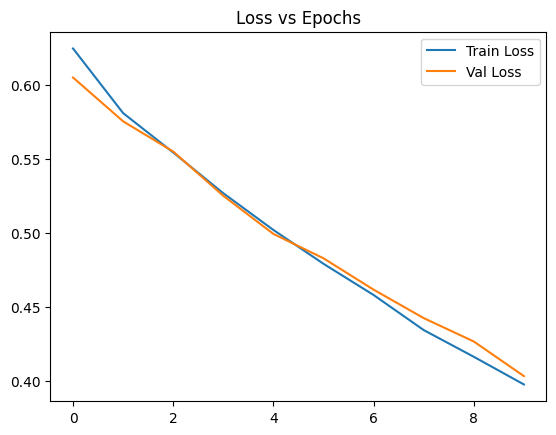

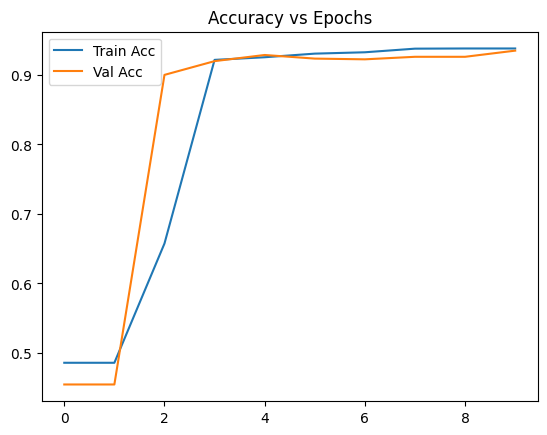

In [34]:
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss vs Epochs")
plt.show()

plt.figure()
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("Accuracy vs Epochs")
plt.show()


Classification Report:

              precision    recall  f1-score   support

      benign      0.867     0.968     0.915       500
   malignant      0.964     0.852     0.904       500

    accuracy                          0.910      1000
   macro avg      0.916     0.910     0.910      1000
weighted avg      0.916     0.910     0.910      1000


Confusion Matrix:

[[484  16]
 [ 74 426]]


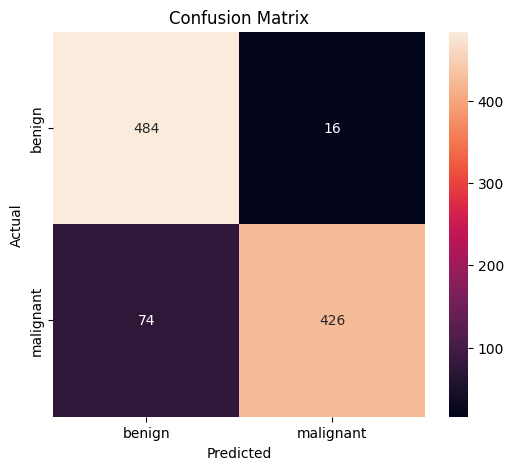

In [35]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ✅ Classification Report
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=3))


# ✅ Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

print("\nConfusion Matrix:\n")
print(cm)


# ✅ Confusion Matrix Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()